# Validación de subsets con todos los modelos

Segunda fase del estudio de selección de variables. Se toman los mejores subsets preseleccionados con MiniBatch K-Means y se validan con los siete algoritmos del proyecto.

Para cada combinación `dataset × subset × modelo × k` se calculan silhouette, Calinski-Harabasz, Davies-Bouldin, tiempo y estabilidad entre semillas mediante Adjusted Rand Index (ARI). Los resultados se guardan incrementalmente para poder reanudar una ejecución interrumpida.

In [1]:
from pathlib import Path
import sys
import time
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.metrics import (
    adjusted_rand_score, silhouette_score,
    calinski_harabasz_score, davies_bouldin_score,
)

def encontrar_raiz(inicio=Path.cwd()):
    for ruta in [inicio, *inicio.parents]:
        if (ruta / "results" / "feature_selection" / "feature_selection_results.csv").exists():
            return ruta
    raise FileNotFoundError("No se encontró la raíz del proyecto.")

ROOT = encontrar_raiz()
sys.path.insert(0, str(ROOT / "code" / "03_modeling"))
import modeling_functions as mf

FEATURE_SELECTION_DIR = ROOT / "results" / "feature_selection"
RESULTS_DIR = ROOT / "results" / "multimodel"
TOP_N_SUBSETS = 5
MIN_FEATURES = 3
SAMPLE_SIZE = 30_000
SILHOUETTE_SAMPLE = 10_000
K_VALUES = range(2, 7)
SEEDS = [42, 123, 2026]
MODELOS = ["kmeans", "minibatch", "bisecting", "birch", "clara", "fuzzy", "gmm"]
REANUDAR = True

DATASETS = {
    "hym": ROOT / "scaled_data" / "hym_scaled.csv",
    "instacart": ROOT / "scaled_data" / "instacart_scaled.csv",
}
DETALLE_PATH = RESULTS_DIR / "multi_model_feature_validation_detail.csv"
RESUMEN_PATH = RESULTS_DIR / "multi_model_feature_validation.csv"
RECOMENDACION_PATH = RESULTS_DIR / "multi_model_recommended_features.csv"
sns.set_theme(style="whitegrid")

## 1. Preselección de candidatos

In [2]:
seleccion_previa = pd.read_csv(FEATURE_SELECTION_DIR / "feature_selection_results.csv")
ranking_previo = (
    seleccion_previa.loc[seleccion_previa["n_features"] >= MIN_FEATURES]
    .groupby(["dataset", "subset", "columns", "n_features"], as_index=False)
    .agg(score_previo=("score", "mean"), score_previo_std=("score", "std"))
    .sort_values(["dataset", "score_previo"], ascending=[True, False])
)
# Dos nombres distintos pueden representar exactamente las mismas columnas.
ranking_previo["column_signature"] = ranking_previo["columns"].apply(
    lambda texto: " | ".join(sorted(c.strip() for c in texto.split("|")))
)
candidatos = (
    ranking_previo.drop_duplicates(["dataset", "column_signature"])
    .groupby("dataset", group_keys=False).head(TOP_N_SUBSETS)
    .drop(columns="column_signature").reset_index(drop=True)
)
display(candidatos)

,dataset,subset,columns,n_features,score_previo,score_previo_std
0,hym,acumulativo libre 3,channel_2_ratio | std_days_between_purchases |...,3,66.562,13.029270
1,hym,base + std_days_between_purchases,recency | frequency | monetary | std_days_betw...,4,64.086,7.175997
2,hym,acumulativo libre 4,channel_2_ratio | std_days_between_purchases |...,4,60.322,6.524735
3,hym,acumulativo condicionado 2,recency | frequency | monetary | std_days_betw...,5,58.604,4.999443
4,hym,base completa,recency | frequency | monetary,3,58.280,2.884996
5,instacart,acumulativo libre 3,recency | frequency | avg_days_between_orders,3,69.146,0.348827
6,instacart,acumulativo libre 4,recency | frequency | avg_days_between_orders ...,4,66.666,2.191148
7,instacart,acumulativo condicionado 2,recency | frequency | avg_basket_size | unique...,5,59.224,1.178974
8,instacart,base + unique_products,recency | frequency | avg_basket_size | unique...,4,54.728,9.844695
9,instacart,base completa,recency | frequency | avg_basket_size,3,52.250,13.992852


## 2. Evaluación multimodelo

El muestreo se realiza una sola vez por dataset y es idéntico para todos los subsets y modelos. Si un algoritmo opcional no está instalado, se registra el error y el resto del estudio continúa.

In [3]:
def evaluar_configuracion(X, dataset, subset, columnas, modelo, k):
    ejecuciones = []
    etiquetas = []
    for seed in SEEDS:
        inicio = time.perf_counter()
        try:
            mf.RANDOM_STATE = seed
            _, labels = mf.fit_clustering_model(modelo, k, X)
            labels = np.asarray(labels)
            if np.unique(labels).size < 2:
                raise ValueError("El modelo produjo menos de dos clusters.")
            ejecuciones.append({
                "dataset": dataset, "subset": subset,
                "columns": " | ".join(columnas),
                "n_features": len(columnas), "model": modelo,
                "k": k, "seed": seed,
                "silhouette": silhouette_score(
                    X, labels, sample_size=min(SILHOUETTE_SAMPLE, len(X)), random_state=seed
                ),
                "calinski_harabasz": calinski_harabasz_score(X, labels),
                "davies_bouldin": davies_bouldin_score(X, labels),
                "time_seconds": time.perf_counter() - inicio,
                "error": "",
            })
            etiquetas.append((seed, labels))
        except Exception as error:
            warnings.warn(f"{dataset}/{subset}/{modelo}/k={k}/seed={seed}: {error}")
            ejecuciones.append({
                "dataset": dataset, "subset": subset,
                "columns": " | ".join(columnas),
                "n_features": len(columnas), "model": modelo,
                "k": k, "seed": seed,
                "silhouette": np.nan, "calinski_harabasz": np.nan,
                "davies_bouldin": np.nan,
                "time_seconds": time.perf_counter() - inicio,
                "error": f"{type(error).__name__}: {error}",
            })
    pares_ari = [adjusted_rand_score(a, b) for (_, a), (_, b) in combinations(etiquetas, 2)]
    estabilidad = np.mean(pares_ari) if pares_ari else np.nan
    for fila in ejecuciones:
        fila["stability_ari"] = estabilidad
    return ejecuciones

columnas_clave = ["dataset", "subset", "model", "k", "seed"]
if REANUDAR and DETALLE_PATH.exists():
    detalle = pd.read_csv(DETALLE_PATH)
else:
    detalle = pd.DataFrame()

completadas = set()
if not detalle.empty:
    completadas = set(map(tuple, detalle[columnas_clave].astype(str).to_numpy()))

for dataset, grupo in candidatos.groupby("dataset"):
    todas_columnas = sorted({c.strip() for texto in grupo["columns"] for c in texto.split("|")})
    datos = pd.read_csv(DATASETS[dataset], usecols=todas_columnas)
    datos = datos.sample(n=min(SAMPLE_SIZE, len(datos)), random_state=42).reset_index(drop=True)
    for _, candidato in grupo.iterrows():
        columnas = [c.strip() for c in candidato["columns"].split("|")]
        X = datos[columnas].to_numpy(dtype=np.float64)
        for modelo in MODELOS:
            for k in K_VALUES:
                claves = {(dataset, candidato["subset"], modelo, str(k), str(seed)) for seed in SEEDS}
                if claves.issubset(completadas):
                    continue
                print(f"{dataset} | {candidato['subset']} | {modelo} | k={k}")
                nuevas = pd.DataFrame(evaluar_configuracion(X, dataset, candidato["subset"], columnas, modelo, k))
                if not detalle.empty:
                    misma = np.logical_and.reduce([
                        detalle[col].astype(str).isin(nuevas[col].astype(str)) for col in columnas_clave
                    ])
                    detalle = detalle.loc[~misma]
                detalle = pd.concat([detalle, nuevas], ignore_index=True)
                detalle.to_csv(DETALLE_PATH, index=False)
                completadas.update(map(tuple, nuevas[columnas_clave].astype(str).to_numpy()))

print(f"Detalle guardado en: {DETALLE_PATH}")

Detalle guardado en: C:\Users\Usuario\Desktop\TFM\results\multi_model_feature_validation_detail.csv


## 3. Ranking comparable y recomendación final

In [4]:
validos = detalle.loc[detalle["error"].fillna("") == ""].copy()
# Ignora filas antiguas del checkpoint que ya no pertenezcan a los candidatos deduplicados.
validos = validos.merge(
    candidatos[["dataset", "subset"]].drop_duplicates(),
    on=["dataset", "subset"], how="inner", validate="many_to_one",
)
resumen = (
    validos.groupby(["dataset", "subset", "columns", "n_features", "model", "k"], as_index=False)
    .agg(
        silhouette=("silhouette", "mean"),
        silhouette_std=("silhouette", "std"),
        calinski_harabasz=("calinski_harabasz", "mean"),
        davies_bouldin=("davies_bouldin", "mean"),
        stability_ari=("stability_ari", "mean"),
        time_seconds=("time_seconds", "mean"),
        successful_seeds=("seed", "nunique"),
    )
)
# Un único score comparable para todas las configuraciones del mismo dataset.
# Cada métrica aporta el 25 %. Los percentiles evitan mezclar escalas numéricas.
grupos = resumen.groupby("dataset")
resumen["pct_silhouette"] = grupos["silhouette"].rank(pct=True, ascending=True)
resumen["pct_calinski"] = grupos["calinski_harabasz"].rank(pct=True, ascending=True)
resumen["pct_davies"] = grupos["davies_bouldin"].rank(pct=True, ascending=False)
resumen["pct_stability"] = grupos["stability_ari"].rank(pct=True, ascending=True)
resumen["score_general"] = (100 * resumen[[
    "pct_silhouette", "pct_calinski", "pct_davies", "pct_stability"
]].mean(axis=1)).round(2)
resumen.to_csv(RESUMEN_PATH, index=False)

ranking_general = resumen.sort_values(
    ["dataset", "score_general", "stability_ari", "silhouette"],
    ascending=[True, False, False, False],
).reset_index(drop=True)
mejores = ranking_general.groupby("dataset", as_index=False).first()
recomendacion = mejores.rename(columns={
    "score_general": "score", "model": "best_model",
    "k": "best_k", "stability_ari": "best_stability_ari",
})[["dataset", "subset", "columns", "n_features", "score",
    "best_model", "best_k", "silhouette", "calinski_harabasz",
    "davies_bouldin", "best_stability_ari"]]
recomendacion.to_csv(RECOMENDACION_PATH, index=False)
display(Markdown("### Mejor configuración general por dataset"))
display(recomendacion.round(3))
print(f"Resumen: {RESUMEN_PATH}\nRecomendación: {RECOMENDACION_PATH}")

### Mejor configuración general por dataset

,dataset,subset,columns,n_features,score,best_model,best_k,silhouette,calinski_harabasz,davies_bouldin,best_stability_ari
0,hym,acumulativo libre 3,channel_2_ratio | std_days_between_purchases |...,3,97.21,fuzzy,5,0.652,55333.585,0.567,1.0
1,instacart,acumulativo libre 4,recency | frequency | avg_days_between_orders ...,4,97.00,fuzzy,2,0.406,29412.557,0.954,1.0


Resumen: C:\Users\Usuario\Desktop\TFM\results\multi_model_feature_validation.csv
Recomendación: C:\Users\Usuario\Desktop\TFM\results\multi_model_recommended_features.csv


## 4. Resultados por modelo y visualizaciones

### Mejor configuración de cada modelo

,dataset,model,subset,k,score_general,silhouette,davies_bouldin,stability_ari
0,hym,birch,base completa,2,70.14,0.494,0.741,0.971
1,hym,bisecting,acumulativo libre 3,6,91.14,0.647,0.524,0.999
2,hym,clara,acumulativo libre 3,5,76.57,0.599,0.670,0.716
3,hym,fuzzy,acumulativo libre 3,5,97.21,0.652,0.567,1.000
4,hym,gmm,base + std_days_between_purchases,2,88.79,0.526,0.722,1.000
5,hym,kmeans,acumulativo libre 3,5,96.14,0.652,0.565,1.000
6,hym,minibatch,acumulativo libre 3,5,84.29,0.652,0.579,0.972
7,instacart,birch,acumulativo libre 4,2,85.43,0.405,0.942,0.948
8,instacart,bisecting,acumulativo libre 3,2,92.57,0.407,0.965,0.998
9,instacart,clara,acumulativo libre 3,2,77.00,0.401,0.969,0.585


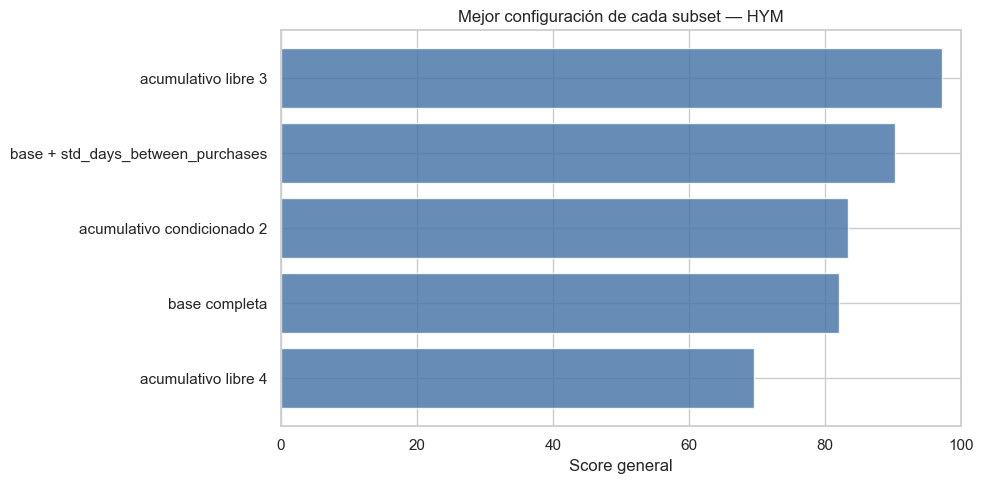

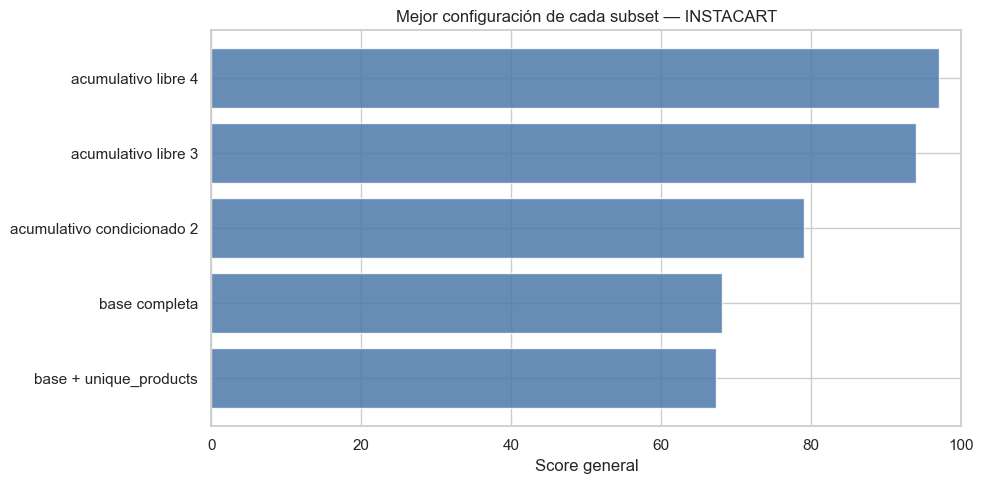

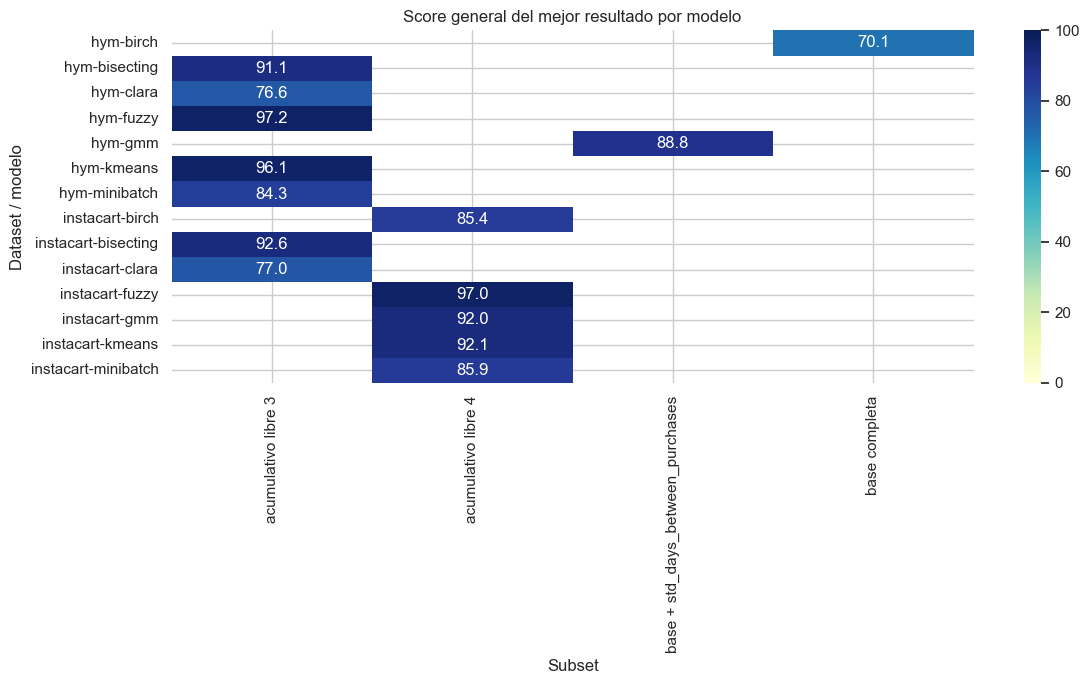

In [5]:
mejor_por_modelo = (
    resumen.sort_values(["dataset", "model", "score_general", "stability_ari"], ascending=[True, True, False, False])
    .groupby(["dataset", "model"], as_index=False).first()
)
display(Markdown("### Mejor configuración de cada modelo"))
display(mejor_por_modelo[["dataset", "model", "subset", "k", "score_general", "silhouette", "davies_bouldin", "stability_ari"]].round(3))

mejor_por_subset = (
    resumen.sort_values(["dataset", "subset", "score_general"], ascending=[True, True, False])
    .groupby(["dataset", "subset"], as_index=False).first()
)
for dataset, datos in mejor_por_subset.groupby("dataset"):
    plt.figure(figsize=(10, 5))
    orden = datos.sort_values("score_general", ascending=True)
    plt.barh(orden["subset"], orden["score_general"], color="#4C78A8", alpha=.85)
    plt.title(f"Mejor configuración de cada subset — {dataset.upper()}")
    plt.xlabel("Score general")
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()

tabla_calor = mejor_por_modelo.pivot(index=["dataset", "model"], columns="subset", values="score_general")
plt.figure(figsize=(12, 7))
sns.heatmap(tabla_calor, annot=True, fmt=".1f", cmap="YlGnBu", vmin=0, vmax=100)
plt.title("Score general del mejor resultado por modelo")
plt.xlabel("Subset")
plt.ylabel("Dataset / modelo")
plt.tight_layout()
plt.show()